## 1. Analisis Permasalahan

A. Masalah yang Ditemukan

Berdasarkan dokumen proyek dan dataset yang dikirim, ada lima masalah utama pada proyek ini,antara lain :
1. Pencari kerja bingung menentukan arah karir karena memiliki skill tapi tidak tahu pekerjaan apa yang cocok. Sebagai contoh, mahasiswa yang menguasai Python dan SQL tidak mengetahui bahwa skill tersebut cocok untuk posisi Data Analyst atau Data Engineer.
2. Pencari kerja tidak tahu skill apa yang harus dipelajari lebih dulu ketika melihat lowongan Data Scientist yang membutuhkan 20 skill sementara mereka hanya memiliki 5 skill.
3. Terjadi ketidakcocokan antara skill yang dimiliki pencari kerja dengan skill yang dibutuhkan industri. Akibatnya perusahaan kesulitan mencari karyawan dan pencari kerja kesulitan mendapatkan pekerjaan.
4. Belum ada sistem yang memberikan rekomendasi dua arah. Sistem yang ada saat ini hanya menampilkan info lowongan tanpa memberikan arahan skill apa saja yang kurang untuk bisa melamar pekerjaan tertentu.
5. Dari sisi teknis, dataset yang tersedia sebenarnya lengkap karena memiliki kolom job title, deskripsi, dan skill. Namun format kolom skill masih berupa teks yang perlu dibersihkan terlebih dahulu sebelum dapat diproses oleh sistem.

B. Kondisi Dataset
Dataset yang digunakan dalam proyek ini memiliki struktur dan karakteristik sebagai berikut.
1. Terdapat lima kolom utama dalam dataset yaitu job_id, category, job_title, job_description, dan job_skill_set.
2. Kolom job_id berisi nomor unik untuk setiap pekerjaan dan jumlah baris dalam dataset mencapai ribuan entri.
3. Kolom category berisi kategori pekerjaan seperti HR, Information Technology, dan lainnya yang berguna untuk melakukan filtering rekomendasi.
4. Kolom job_title berisi nama pekerjaan spesifik seperti "Human Resources Generalist" atau "Data Scientist".
5. Kolom job_skill_set adalah kolom paling penting untuk sistem rekomendasi karena berisi daftar skill yang dibutuhkan dalam format list Python seperti ['Python', 'SQL', 'Machine Learning'], namun saat ini masih berupa string teks yang perlu diparsing terlebih dahulu.



C. Solusi yang Diusulkan
Berdasarkan lima masalah yang telah diidentifikasi, berikut adalah lima solusi yang akan diterapkan dalam proyek ini.
1. Melakukan normalisasi teks pada input skill pengguna dengan mengubah semua huruf menjadi kecil, menghapus spasi berlebih, dan memecah teks berdasarkan koma. Contohnya input "Python, SQL, Machine Learning" akan diubah menjadi list ['python', 'sql', 'machine learning'].
2. Mengubah daftar skill dari dataset dan skill pengguna menjadi vektor numerik menggunakan metode TF-IDF Vectorizer yang mampu menangani teks pendek seperti daftar skill.
3. Menghitung nilai kemiripan antara vektor skill pengguna dengan vektor skill setiap pekerjaan menggunakan metode Cosine Similarity yang menghasilkan nilai antara 0 hingga 1, dimana nilai yang mendekati 1 menandakan kemiripan yang tinggi.
4. Mengurutkan seluruh pekerjaan berdasarkan nilai similarity tertinggi ke terendah dan menampilkan 5 hingga 10 rekomendasi teratas kepada pengguna melalui dashboard.
5. Menghitung skill gap dengan membandingkan skill yang dimiliki pengguna terhadap skill yang dibutuhkan setiap pekerjaan, kemudian menampilkan skill yang belum dikuasai pengguna sebagai rekomendasi belajar.


# 2. Mendefinisikan Pertanyaan Bisnis

1. Apa saja 10 pekerjaan yang paling banyak tersedia berdasarkan jumlah lowongan di dataset?
2. Kategori pekerjaan mana yang memiliki jumlah lowongan terbanyak?
3. Apa saja 15 skill yang paling sering diminta oleh perusahaan di seluruh lowongan pekerjaan?
4. Bagaimana perbandingan jumlah hard skill dan soft skill yang diminta di pasar kerja?
5. Untuk kategori pekerjaan Data Science, apa saja 5 skill yang paling dominan diminta?
6. Untuk kategori pekerjaan HR, apa saja 5 skill yang paling dominan diminta?
7. Jika pengguna memiliki skill Excel, HR, dan Recruitment, pekerjaan apa yang paling sesuai dan berapa persen tingkat kecocokannya?
8. Skill apa saja yang perlu dipelajari pengguna untuk dapat bekerja sebagai HR Manager berdasarkan skill yang sudah dimilikinya?

# 3.  Melakukan Exploratory Data Analysis (EDA)

In [1]:
#Import Library
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

plt.style.use('ggplot')
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (12, 6)

print("Library berhasil diimport")

Library berhasil diimport


In [4]:
#Memuat dataset
df = pd.read_csv('all_job_post.csv')

print(f"Jumlah baris: {len(df)}")
print(f"Jumlah kolom: {len(df.columns)}")
print(f"Nama kolom: {list(df.columns)}")
df.head()

Jumlah baris: 1167
Jumlah kolom: 5
Nama kolom: ['job_id', 'category', 'job_title', 'job_description', 'job_skill_set']


,job_id,category,job_title,job_description,job_skill_set
0,3902668440,HR,Sr Human Resource Generalist,SUMMARY\nTHE SR. HR GENERALIST PROVIDES HR EXP...,"['employee relations', 'talent acquisition', '..."
1,3905823748,HR,Human Resources Manager,BE PART OF A STELLAR TEAM AT YSB AS THE MANAGE...,"['Talent Acquisition', 'Employee Performance M..."
2,3905854799,HR,Director of Human Resources,OUR CLIENT IS A THRIVING ORGANIZATION OFFERING...,"['Human Resources Management', 'Recruitment', ..."
3,3905834061,HR,Chief Human Resources Officer,JOB TITLE: CHIEF HUMAN RESOURCES OFFICER (CHRO...,"['talent management', 'organizational developm..."
4,3906250451,HR,Human Resources Generalist (Hybrid Role),DESCRIPTION\n\n WHO WE ARE \n\nAVI-SPL IS A DI...,"['Microsoft Office', 'Data analysis', 'Employe..."


In [5]:
#Cek Missing Value
print("Missing value per kolom:")
print(df.isnull().sum())

Missing value per kolom:
job_id             0
category           0
job_title          0
job_description    0
job_skill_set      0
dtype: int64


In [6]:
#Parsing Kolom Skill
def parse_skill_column(skill_str):
    if pd.isna(skill_str):
        return []
    try:
        if isinstance(skill_str, str):
            return ast.literal_eval(skill_str)
        else:
            return []
    except:
        return []

df['job_skill_set_parsed'] = df['job_skill_set'].apply(parse_skill_column)
df['num_skills'] = df['job_skill_set_parsed'].apply(len)

print("Contoh hasil parsing:")
print(df[['job_title', 'job_skill_set_parsed', 'num_skills']].head(3))

Contoh hasil parsing:
                      job_title  \
0  Sr Human Resource Generalist   
1       Human Resources Manager   
2   Director of Human Resources   

                                job_skill_set_parsed  num_skills  
0  [employee relations, talent acquisition, perfo...          27  
1  [Talent Acquisition, Employee Performance Mana...          16  
2  [Human Resources Management, Recruitment, Empl...          20  


In [7]:
#Statistik Jumlah Skill Per pekerjaan
print(f"Rata-rata skill per pekerjaan: {df['num_skills'].mean():.2f}")
print(f"Minimum skill: {df['num_skills'].min()}")
print(f"Maksimum skill: {df['num_skills'].max()}")

Rata-rata skill per pekerjaan: 17.85
Minimum skill: 5
Maksimum skill: 43


In [8]:
#Analisis Kategori Pekerjaan
category_counts = df['category'].value_counts()
print("Jumlah lowongan per kategori:")
print(category_counts)

Jumlah lowongan per kategori:
category
INFORMATION-TECHNOLOGY    240
BUSINESS-DEVELOPMENT      239
FINANCE                   236
SALES                     232
HR                        220
Name: count, dtype: int64


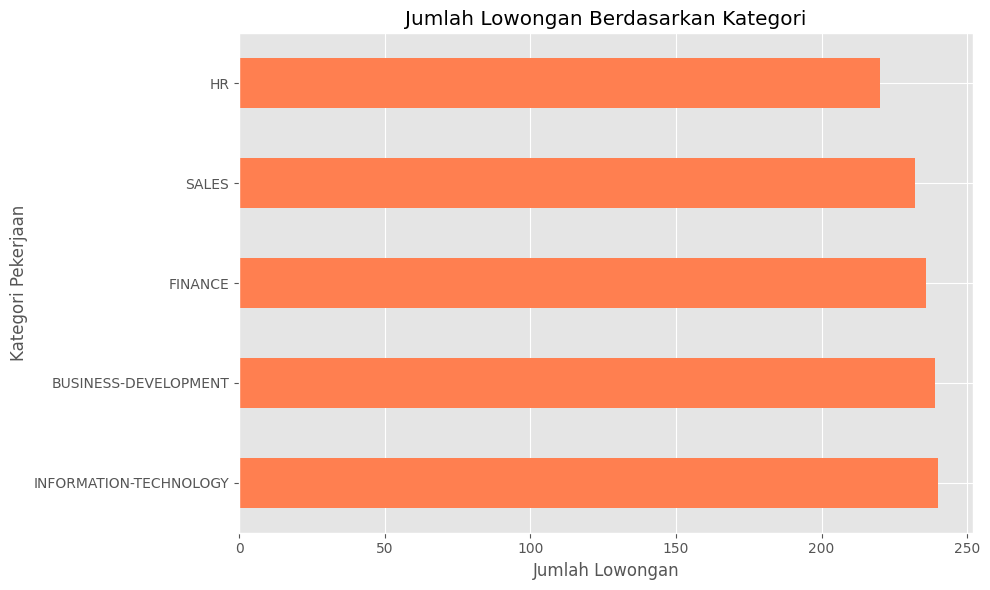

In [9]:
#Visualisasi Kategori Pekerjaan
plt.figure(figsize=(10, 6))
category_counts.plot(kind='barh', color='coral')
plt.xlabel('Jumlah Lowongan')
plt.ylabel('Kategori Pekerjaan')
plt.title('Jumlah Lowongan Berdasarkan Kategori')
plt.tight_layout()
plt.show()

In [10]:
#Analisis Job Berdasarkan Popularitas
jobtitle_counts = df['job_title'].value_counts().head(10)
print("10 Job Title dengan lowongan terbanyak:")
print(jobtitle_counts)

10 Job Title dengan lowongan terbanyak:
job_title
Business Development Manager                 53
Human Resources Generalist                   34
Business Development Representative          33
Human Resources Manager                      28
Information Technology Support Specialist    16
Finance Manager                              15
Human Resources Business Partner             15
Director of Finance                          13
Human Resources Coordinator                  11
Information Technology Project Manager       11
Name: count, dtype: int64


In [11]:
#Kumpulkan semua skill dari dataset
all_skills = []
for skill_list in df['job_skill_set_parsed']:
    all_skills.extend(skill_list)

print(f"Total skill unik: {len(set(all_skills))}")
print(f"Total kemunculan skill: {len(all_skills)}")

Total skill unik: 5774
Total kemunculan skill: 20833


In [12]:
#Skill Paling Banyak Diminta
skill_counts = Counter(all_skills).most_common(15)
print("15 Skill paling banyak diminta:")
for skill, count in skill_counts:
    print(f"  {skill}: {count} lowongan")

15 Skill paling banyak diminta:
  communication: 783 lowongan
  problem solving: 609 lowongan
  teamwork: 430 lowongan
  adaptability: 413 lowongan
  Communication: 309 lowongan
  Problem Solving: 251 lowongan
  leadership: 240 lowongan
  time management: 219 lowongan
  customer service: 218 lowongan
  collaboration: 215 lowongan
  relationship building: 214 lowongan
  interpersonal skills: 205 lowongan
  data analysis: 184 lowongan
  Adaptability: 175 lowongan
  attention to detail: 171 lowongan


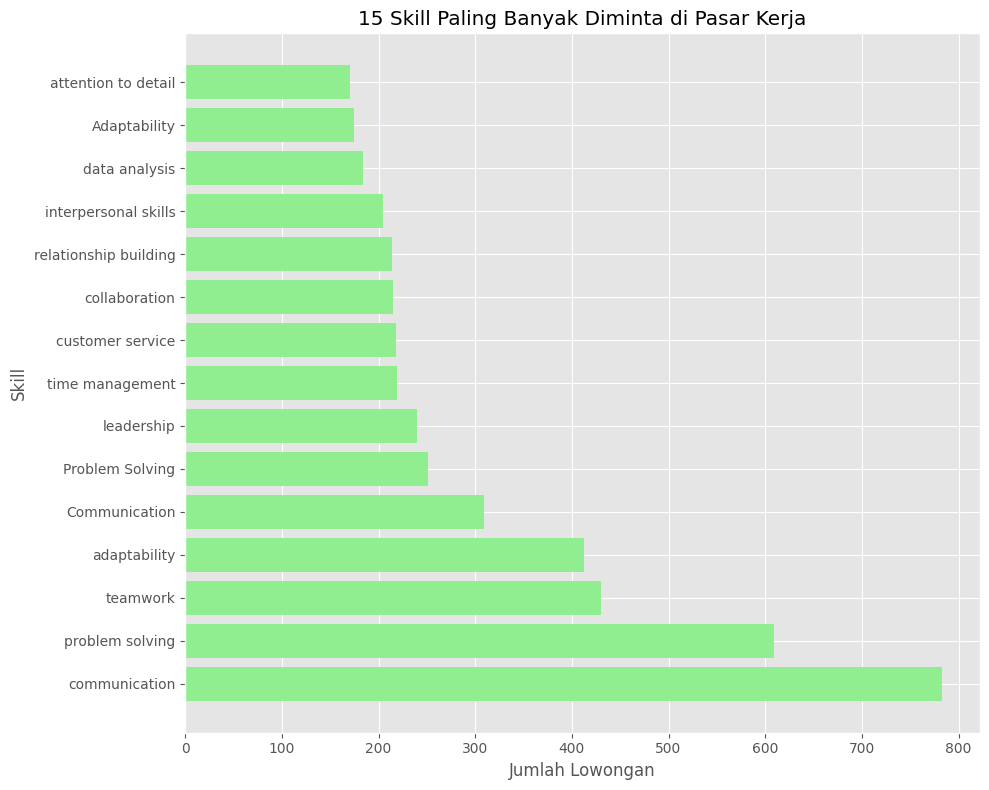

In [13]:
# Visualisasi 15 Skill Paling Banyak Diminta
skills, counts = zip(*skill_counts)
plt.figure(figsize=(10, 8))
plt.barh(skills, counts, color='lightgreen')
plt.xlabel('Jumlah Lowongan')
plt.ylabel('Skill')
plt.title('15 Skill Paling Banyak Diminta di Pasar Kerja')
plt.tight_layout()
plt.show()

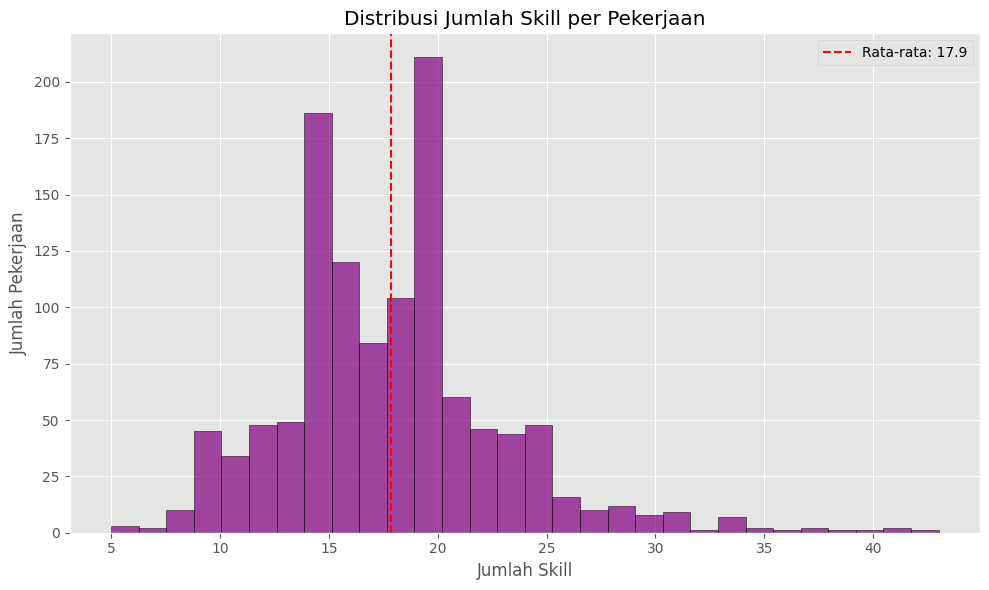

In [14]:
# Histogram Distribusi Jumlah Skill per Pekerjaan
plt.figure(figsize=(10, 6))
plt.hist(df['num_skills'], bins=30, color='purple', edgecolor='black', alpha=0.7)
plt.xlabel('Jumlah Skill')
plt.ylabel('Jumlah Pekerjaan')
plt.title('Distribusi Jumlah Skill per Pekerjaan')
plt.axvline(df['num_skills'].mean(), color='red', linestyle='dashed', label=f'Rata-rata: {df["num_skills"].mean():.1f}')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# Analisis Skill Kategori HR
df_hr = df[df['category'] == 'HR']
all_skills_hr = []
for skill_list in df_hr['job_skill_set_parsed']:
    all_skills_hr.extend(skill_list)
skill_counts_hr = Counter(all_skills_hr).most_common(10)

print("10 Skill paling banyak diminta di kategori HR:")
for skill, count in skill_counts_hr:
    print(f"  {skill}: {count} lowongan")

10 Skill paling banyak diminta di kategori HR:
  communication: 117 lowongan
  problem solving: 93 lowongan
  Communication: 90 lowongan
  Problem Solving: 72 lowongan
  teamwork: 63 lowongan
  interpersonal skills: 58 lowongan
  employee relations: 55 lowongan
  Adaptability: 54 lowongan
  attention to detail: 51 lowongan
  adaptability: 48 lowongan


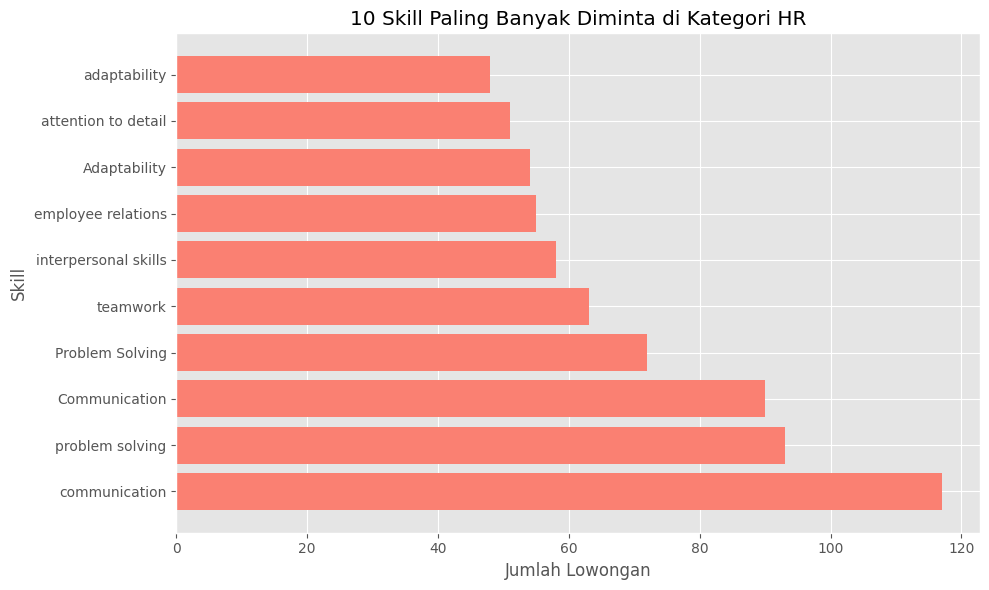

In [16]:
# Visualisasi Skill Kategori HR
skills_hr, counts_hr = zip(*skill_counts_hr)
plt.figure(figsize=(10, 6))
plt.barh(skills_hr, counts_hr, color='salmon')
plt.xlabel('Jumlah Lowongan')
plt.ylabel('Skill')
plt.title('10 Skill Paling Banyak Diminta di Kategori HR')
plt.tight_layout()
plt.show()

In [17]:
# Analisis Skill Kategori Information Technology
df_it = df[df['category'] == 'INFORMATION-TECHNOLOGY']
all_skills_it = []
for skill_list in df_it['job_skill_set_parsed']:
    all_skills_it.extend(skill_list)
skill_counts_it = Counter(all_skills_it).most_common(10)

print("10 Skill paling banyak diminta di kategori Information Technology:")
for skill, count in skill_counts_it:
    print(f"  {skill}: {count} lowongan")

10 Skill paling banyak diminta di kategori Information Technology:
  communication: 123 lowongan
  problem solving: 104 lowongan
  Communication: 96 lowongan
  Problem Solving: 85 lowongan
  adaptability: 64 lowongan
  teamwork: 56 lowongan
  project management: 54 lowongan
  collaboration: 49 lowongan
  Adaptability: 48 lowongan
  Teamwork: 45 lowongan


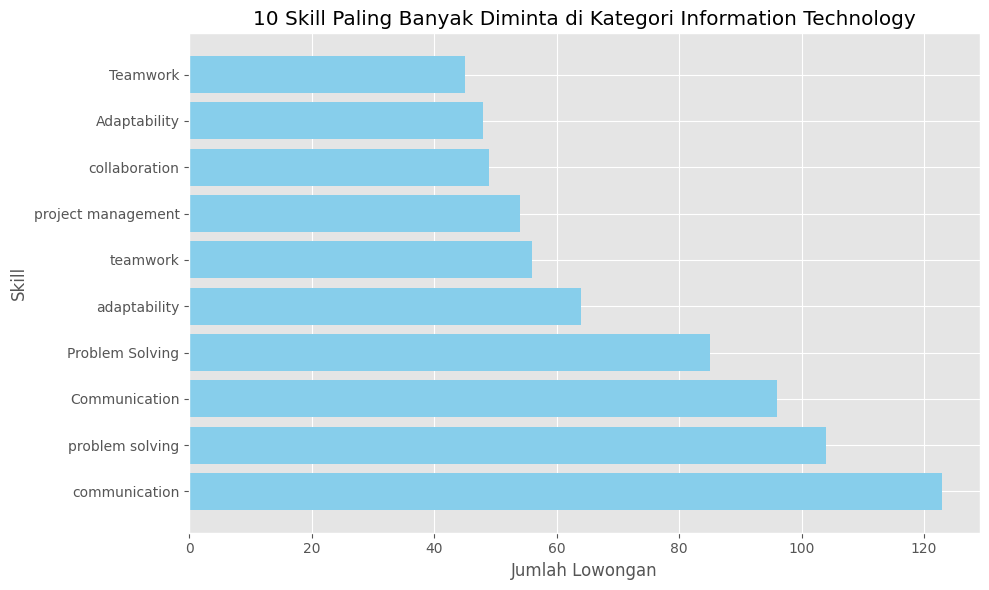

In [18]:
# Visualisasi Skill Kategori Information Technology
skills_it, counts_it = zip(*skill_counts_it)
plt.figure(figsize=(10, 6))
plt.barh(skills_it, counts_it, color='skyblue')
plt.xlabel('Jumlah Lowongan')
plt.ylabel('Skill')
plt.title('10 Skill Paling Banyak Diminta di Kategori Information Technology')
plt.tight_layout()
plt.show()

In [19]:
# Ringkasan Akhir EDA
print("="*50)
print("RINGKASAN AKHIR EKSPLORASI DATA")
print("="*50)

print(f"1. Total lowongan dalam dataset: {len(df)}")
print(f"2. Jumlah kategori pekerjaan unik: {df['category'].nunique()}")
print(f"3. Kategori dengan lowongan terbanyak: {category_counts.index[0]} ({category_counts.iloc[0]} lowongan)")
print(f"4. Job title dengan lowongan terbanyak: {jobtitle_counts.index[0]} ({jobtitle_counts.iloc[0]} lowongan)")
print(f"5. Skill paling banyak diminta secara keseluruhan: {skill_counts[0][0]} ({skill_counts[0][1]} lowongan)")
print(f"6. Rata-rata jumlah skill per pekerjaan: {df['num_skills'].mean():.2f}")
print(f"7. Total skill unik dalam dataset: {len(set(all_skills))}")
print(f"8. Kategori HR memiliki skill terbanyak: {skill_counts_hr[0][0]} ({skill_counts_hr[0][1]} lowongan)")
print(f"9. Kategori IT memiliki skill terbanyak: {skill_counts_it[0][0]} ({skill_counts_it[0][1]} lowongan)")

RINGKASAN AKHIR EKSPLORASI DATA
1. Total lowongan dalam dataset: 1167
2. Jumlah kategori pekerjaan unik: 5
3. Kategori dengan lowongan terbanyak: INFORMATION-TECHNOLOGY (240 lowongan)
4. Job title dengan lowongan terbanyak: Business Development Manager (53 lowongan)
5. Skill paling banyak diminta secara keseluruhan: communication (783 lowongan)
6. Rata-rata jumlah skill per pekerjaan: 17.85
7. Total skill unik dalam dataset: 5774
8. Kategori HR memiliki skill terbanyak: communication (117 lowongan)
9. Kategori IT memiliki skill terbanyak: communication (123 lowongan)


In [20]:
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 78.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 109.9 MB/s eta 0:00:00


In [21]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import ast
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Konfigurasi halaman
st.set_page_config(page_title="Sistem Rekomendasi Skill dan Karir", layout="wide")

# Title
st.title("Sistem Rekomendasi Skill dan Karir Berbasis AI")
st.markdown("---")

# Load dataset
@st.cache_data
def load_data():
    df = pd.read_csv('all_job_post.csv')

    # Parsing kolom skill
    def parse_skill(skill_str):
        if pd.isna(skill_str):
            return []
        try:
            if isinstance(skill_str, str):
                return ast.literal_eval(skill_str)
            else:
                return []
        except:
            return []

    df['skill_list'] = df['job_skill_set'].apply(parse_skill)
    df['num_skills'] = df['skill_list'].apply(len)

    # Buat kolom teks untuk TF-IDF
    df['skill_text'] = df['skill_list'].apply(lambda x: ' '.join(x).lower())

    return df

df = load_data()

# Sidebar
st.sidebar.header("Menu")
menu = st.sidebar.radio("Pilih Halaman", ["EDA & Market Insight", "Rekomendasi Karir"])

# ============================================================
# HALAMAN 1: EDA & MARKET INSIGHT
# ============================================================
if menu == "EDA & Market Insight":
    st.header("Eksplorasi Data dan Wawasan Pasar Kerja")

    col1, col2, col3, col4 = st.columns(4)
    with col1:
        st.metric("Total Lowongan", len(df))
    with col2:
        st.metric("Kategori Pekerjaan", df['category'].nunique())
    with col3:
        all_skills = [skill for sublist in df['skill_list'] for skill in sublist]
        st.metric("Total Skill Unik", len(set(all_skills)))
    with col4:
        st.metric("Rata-rata Skill per Pekerjaan", f"{df['num_skills'].mean():.1f}")

    st.markdown("---")

    # Kategori pekerjaan
    st.subheader("Jumlah Lowongan Berdasarkan Kategori")
    category_counts = df['category'].value_counts()
    st.bar_chart(category_counts)

    # Job title populer
    st.subheader("10 Pekerjaan dengan Lowongan Terbanyak")
    jobtitle_counts = df['job_title'].value_counts().head(10)
    st.bar_chart(jobtitle_counts)

    # Skill paling banyak diminta
    st.subheader("15 Skill Paling Banyak Diminta")
    all_skills = [skill for sublist in df['skill_list'] for skill in sublist]
    skill_counts = Counter(all_skills).most_common(15)
    skill_df = pd.DataFrame(skill_counts, columns=['Skill', 'Jumlah Lowongan'])
    st.bar_chart(skill_df.set_index('Skill'))

# ============================================================
# HALAMAN 2: REKOMENDASI KARIR
# ============================================================
else:
    st.header("Rekomendasi Pekerjaan Berdasarkan Skill")

    # Input dari user
    user_input = st.text_area("Masukkan skill yang Anda kuasai (pisahkan dengan koma)",
                               placeholder="Contoh: Python, SQL, Machine Learning, Communication")

    if st.button("Cari Pekerjaan"):
        if user_input:
            # Bersihkan input user
            user_skills = [s.strip().lower() for s in user_input.split(',')]
            user_skill_text = ' '.join(user_skills)

            # Siapkan data untuk similarity
            all_skill_texts = df['skill_text'].tolist()
            all_skill_texts.append(user_skill_text)

            # TF-IDF Vectorizer
            vectorizer = TfidfVectorizer()
            tfidf_matrix = vectorizer.fit_transform(all_skill_texts)

            # Hitung similarity
            similarity_scores = cosine_similarity(tfidf_matrix[-1:], tfidf_matrix[:-1]).flatten()

            # Ambil top 5 rekomendasi
            top_indices = similarity_scores.argsort()[-5:][::-1]

            st.subheader("Rekomendasi Pekerjaan untuk Anda")
            st.markdown("---")

            for i, idx in enumerate(top_indices):
                job = df.iloc[idx]
                similarity_percentage = similarity_scores[idx] * 100

                with st.container():
                    st.markdown(f"### {i+1}. {job['job_title']}")
                    st.markdown(f"**Kategori:** {job['category']}")
                    st.markdown(f"**Tingkat Kecocokan:** {similarity_percentage:.1f}%")

                    # Tampilkan skill yang dibutuhkan
                    required_skills = set(job['skill_list'])
                    user_skills_set = set(user_skills)

                    # Skill yang sudah dimiliki
                    matched_skills = required_skills.intersection(user_skills_set)
                    if matched_skills:
                        st.markdown(f"**Skill yang cocok:** {', '.join(matched_skills)}")

                    # Skill gap (belum dimiliki)
                    missing_skills = required_skills - user_skills_set
                    if missing_skills:
                        st.markdown(f"**Skill yang perlu dipelajari:** {', '.join(list(missing_skills)[:5])}")

                    st.markdown("---")
        else:
            st.warning("Silakan masukkan skill terlebih dahulu")

Writing app.py


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦

⠧⠇⠏Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 2026-05-18 07:06:12.398 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.125.160.158:8501

